In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

In [15]:
# ── 1. Class names ──
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']

# ── 2. Load dataset ──
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [16]:
# ── 3. Save labels before one-hot encoding ──
y_train_labels = y_train.copy()
y_test_labels  = y_test.copy()

# ── 4. Normalize (0-255 → 0-1) ──
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# ── 5. Reshape for CNN ──
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# ── 6. One-hot encode labels ──
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)


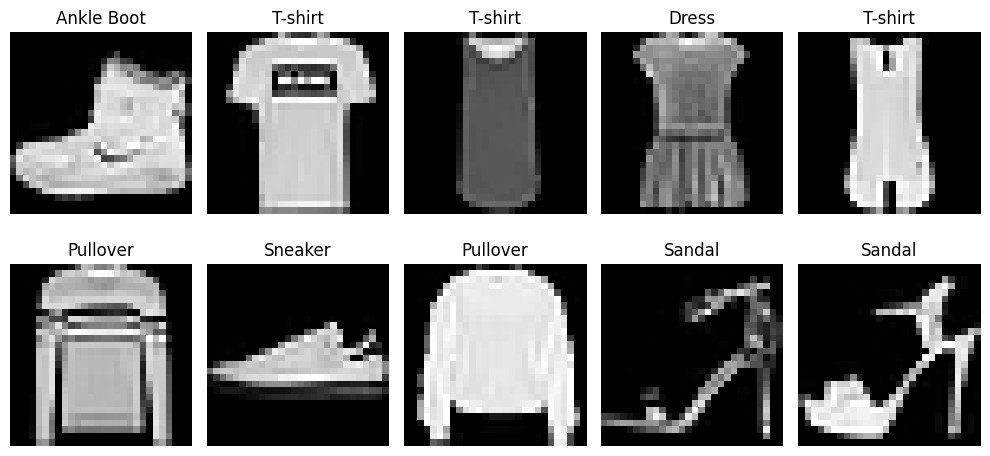

In [19]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train_labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()


In [21]:
# ── 8. Build model ──
model = Sequential([
    Input(shape=(28, 28, 1)),   # ✅ correct way

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ── 9. Compile ──

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ── 10. Train ──
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=128,
                    validation_data=(X_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.8906 - loss: 0.3015 - val_accuracy: 0.8981 - val_loss: 0.2812
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9004 - loss: 0.2752 - val_accuracy: 0.9024 - val_loss: 0.2753
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9049 - loss: 0.2640 - val_accuracy: 0.9027 - val_loss: 0.2597
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9079 - loss: 0.2524 - val_accuracy: 0.9069 - val_loss: 0.2539
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9120 - loss: 0.2419 - val_accuracy: 0.9102 - val_loss: 0.2454


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9087 - loss: 0.2515
Test Accuracy: 0.9102
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


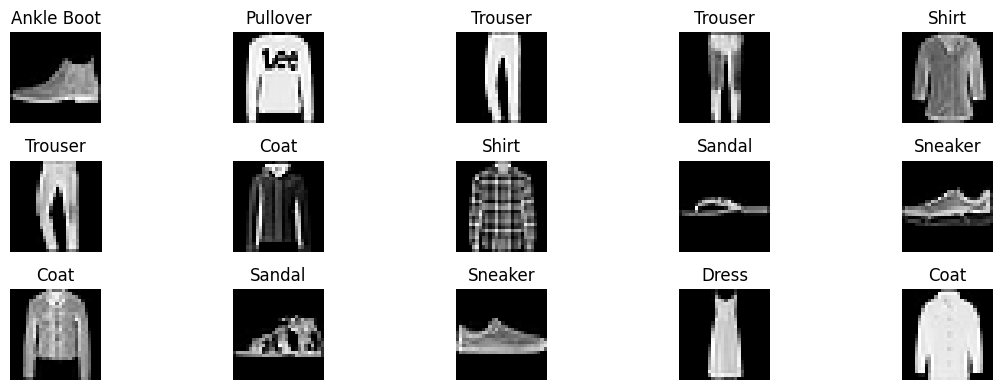

In [31]:
# ── 11. Evaluate ──
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# ── 12. Predict and show results ──
predictions = model.predict(X_test)

plt.figure(figsize=(12, 4))

for i in range(15):  
    plt.subplot(3, 5, i + 1)   
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[np.argmax(predictions[i])])
    plt.axis('off')

plt.tight_layout()
plt.show()
